In [1]:
# SEGMENT 1: Environment Setup
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs, make_moons, make_classification, load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)
print("Setup complete. Libraries loaded.")

Setup complete. Libraries loaded.


In [2]:
# SEGMENT 2: Generate multiple toy datasets to compare behaviors
# ============================================
# Dataset 1: Blobs — well-separated groups (easy case)
X_blobs, y_blobs = make_blobs(n_samples=200, centers=3, cluster_std=1.0, random_state=42)
X_blobs

array([[ 6.50565335,  2.4470026 ],
       [-5.12894273,  9.83618863],
       [-6.89187396, -7.77736396],
       [-8.32771153, -8.28757337],
       [-7.46899195, -6.0305075 ],
       [-6.13233359, -6.26973933],
       [-2.70155859,  9.31583347],
       [-7.3506655 , -6.64805966],
       [ 4.375222  ,  4.69333885],
       [-6.06676507, -6.25048075],
       [ 3.71294836,  1.91364433],
       [ 4.86733877,  3.28031244],
       [ 5.72293008,  3.02697174],
       [ 4.15451529,  2.05504382],
       [ 2.61473625,  2.159624  ],
       [-7.7086222 , -7.44029063],
       [-2.58120774, 10.01781903],
       [-7.70184759, -6.63642238],
       [ 5.32613903,  0.36045381],
       [-5.29361038, -8.11792509],
       [ 6.76203503,  3.00563494],
       [ 4.16493353,  1.31984045],
       [-6.55690863, -7.70734054],
       [-2.44166942,  7.58953794],
       [-6.19767422, -7.19037635],
       [-3.18611962,  9.62596242],
       [-3.6601912 ,  9.38998415],
       [-7.03141229, -6.29179239],
       [-2.30033403,

In [3]:
# Dataset 2: Moons — non-linearly separable groups (harder case)
X_moons, y_moons = make_moons(n_samples=200, noise=0.1, random_state=42)
X_moons

array([[-1.04942573e+00,  8.44426315e-02],
       [ 9.22817545e-01,  4.57488507e-01],
       [ 6.56786593e-01,  6.99596694e-01],
       [ 1.18894020e+00, -3.86528073e-01],
       [ 2.89264549e-01, -1.37744892e-01],
       [ 2.51685082e-01,  1.81006054e-01],
       [-6.68120991e-01,  8.22265447e-01],
       [ 1.55626644e+00, -2.03445580e-01],
       [ 1.87213538e+00, -1.25335230e-01],
       [ 1.43229273e-01,  9.53267512e-01],
       [-4.35091327e-01,  7.43738050e-01],
       [ 1.91161702e+00, -1.05146485e-01],
       [ 1.53432590e+00, -3.97547101e-01],
       [-8.24879535e-01,  5.29607749e-01],
       [ 1.88043395e+00,  1.54681644e-01],
       [ 1.87043050e+00, -9.01427936e-02],
       [-6.84180156e-02,  1.23271872e+00],
       [ 1.04680086e+00, -5.17441448e-01],
       [-1.00198756e+00,  6.32750117e-01],
       [-4.23980382e-01,  7.45855239e-01],
       [ 3.38030046e-01, -6.83719318e-02],
       [ 8.96478204e-01,  5.70936879e-01],
       [ 9.69901385e-01, -6.20552828e-01],
       [-8.

In [4]:
# Dataset 3: Classification-style data with some feature overlap
X_class, y_class = make_classification(n_samples=200, n_features=2, n_redundant=0,
                                        n_informative=2, n_clusters_per_class=1,
                                        n_classes=3, random_state=42)


In [5]:
print("Blobs shape:", X_blobs.shape)
print("Moons shape:", X_moons.shape)
print("Classification shape:", X_class.shape)

Blobs shape: (200, 2)
Moons shape: (200, 2)
Classification shape: (200, 2)


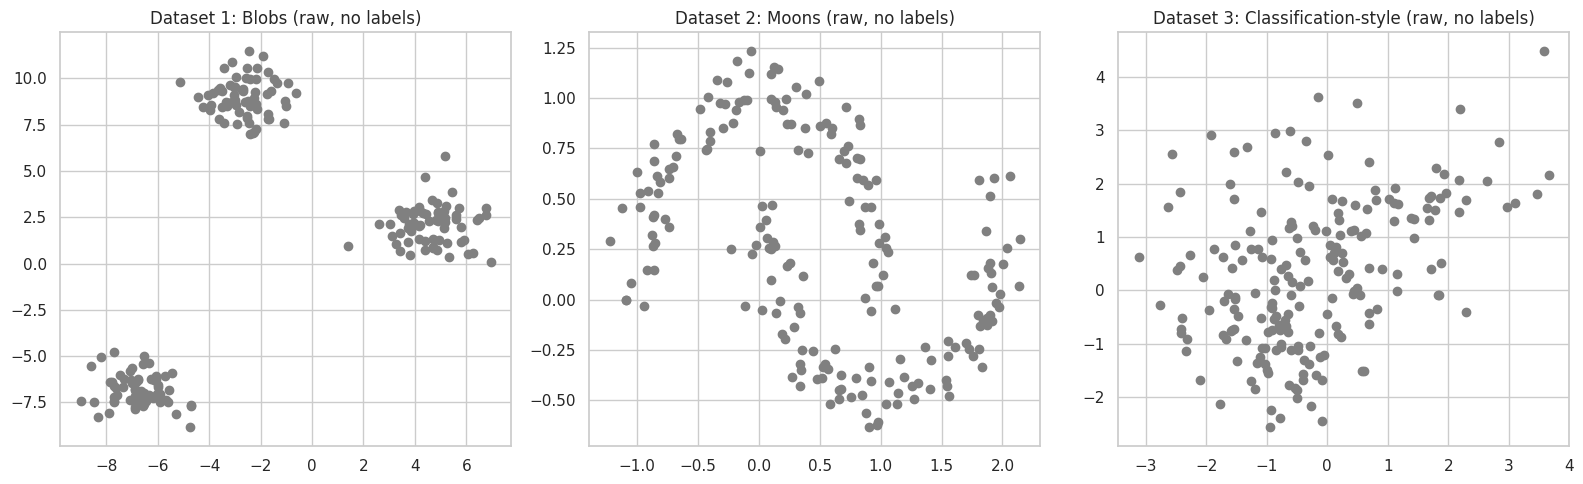

In [6]:
# Visualize all three raw datasets, UNLABELED — like the "no name tags" pile
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c='gray')
axes[0].set_title("Dataset 1: Blobs (raw, no labels)")

axes[1].scatter(X_moons[:, 0], X_moons[:, 1], c='gray')
axes[1].set_title("Dataset 2: Moons (raw, no labels)")

axes[2].scatter(X_class[:, 0], X_class[:, 1], c='gray')
axes[2].set_title("Dataset 3: Classification-style (raw, no labels)")

plt.tight_layout()
plt.show()


In [7]:
# SEGMENT 3A: Supervised Learning with the Iris dataset (real-world example)
# ============================================
iris = load_iris()
X_iris = iris.data[:, :2]   # use only 2 features for easy plotting
y_iris = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X_iris, y_iris, test_size=0.3, random_state=42
)

In [8]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 105
Testing samples: 45


In [9]:
# --- Model 1: K-Nearest Neighbors ---
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_preds = knn.predict(X_test)
knn_preds
knn_acc = knn.score(X_test, y_test)
print(f"KNN Accuracy: {knn_acc * 100:.2f}%")

KNN Accuracy: 77.78%


**Decision Tree Model**

In [10]:
# --- Model 2: Decision Tree ---
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3, random_state=42)
tree.fit(X_train, y_train)
tree_preds = tree.predict(X_test)
tree_acc = tree.score(X_test, y_test)
print(f"Decision Tree Accuracy: {tree_acc * 100:.2f}%")

Decision Tree Accuracy: 75.56%


**Logistic Regression Model**

In [11]:
# --- Model 3: Logistic Regression ---
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train, y_train)
logreg_preds = logreg.predict(X_test)
logreg_acc = logreg.score(X_test, y_test)
print(f"Logistic Regression Accuracy: {logreg_acc * 100:.2f}%")

Logistic Regression Accuracy: 82.22%


In [12]:
# Compare all three supervised models side by side
model_comparison = pd.DataFrame({
    'Model': ['KNN', 'Decision Tree', 'Logistic Regression'],
    'Accuracy': [knn_acc, tree_acc, logreg_acc]
}).sort_values('Accuracy', ascending=False)

print(model_comparison)


                 Model  Accuracy
2  Logistic Regression  0.822222
0                  KNN  0.777778
1        Decision Tree  0.755556


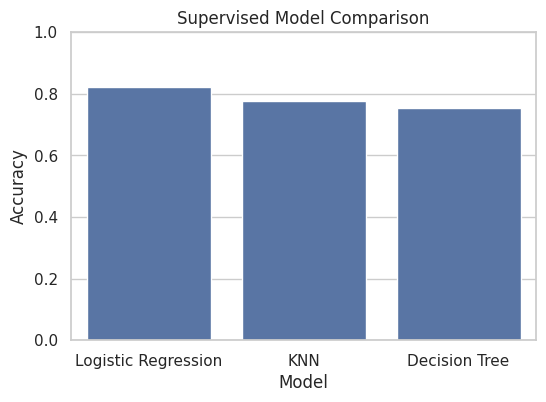

In [13]:
plt.figure(figsize=(6, 4))
sns.barplot(data=model_comparison, x='Model', y='Accuracy')
plt.title("Supervised Model Comparison")
plt.ylim(0, 1)
plt.show()


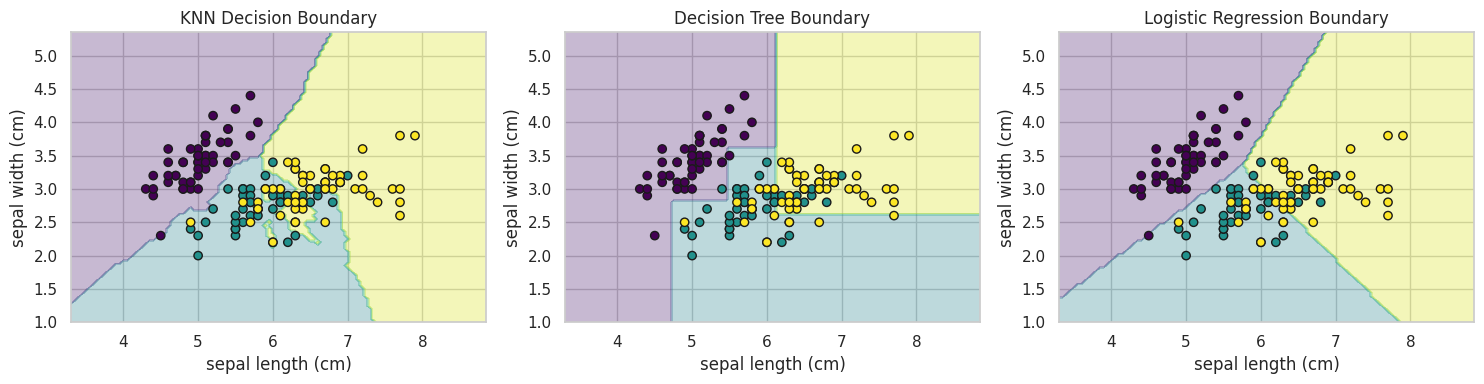

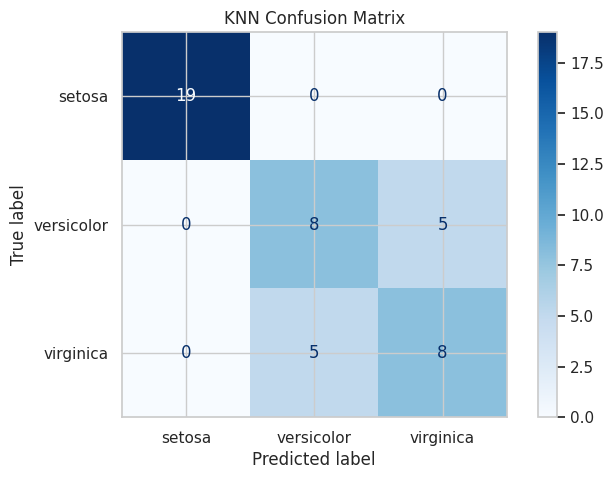

k=1 -> Accuracy: 71.11%
k=20 -> Accuracy: 80.00%


In [14]:
# Visualize decision boundaries — helps students SEE what "learning labels" means
# ============================================
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                          np.arange(y_min, y_max, 0.05))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap='viridis')
    plt.title(title)
    plt.xlabel(iris.feature_names[0])
    plt.ylabel(iris.feature_names[1])

plt.figure(figsize=(15, 4))
plt.subplot(1, 3, 1)
plot_decision_boundary(knn, X_iris, y_iris, "KNN Decision Boundary")
plt.subplot(1, 3, 2)
plot_decision_boundary(tree, X_iris, y_iris, "Decision Tree Boundary")
plt.subplot(1, 3, 3)
plot_decision_boundary(logreg, X_iris, y_iris, "Logistic Regression Boundary")
plt.tight_layout()
plt.show()

# Confusion matrix — shows exactly where the model got confused
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, knn_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)
disp.plot(cmap='Blues')
plt.title("KNN Confusion Matrix")
plt.show()

# --- Hands-on Exercise 2  ---
# "Change n_neighbors in KNN to 1, then to 20. Re-run and observe accuracy
#  and the decision boundary shape. What happens when the model 'looks'
#  at too few vs too many neighbors?"

for k in [1, 20]:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    acc = model.score(X_test, y_test)
    print(f"k={k} -> Accuracy: {acc*100:.2f}%")


**Unsupervised Machine Learning**

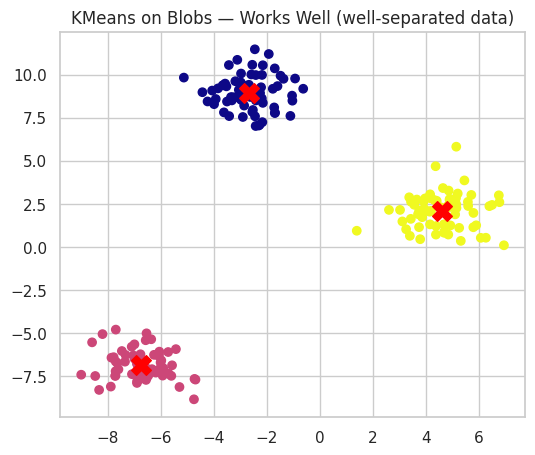

In [15]:
# SEGMENT 5A: KMeans Clustering on Blobs (easy case)
# ============================================
from sklearn.cluster import KMeans

kmeans_blobs = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_blobs.fit(X_blobs)
labels_blobs = kmeans_blobs.labels_

plt.figure(figsize=(6, 5))
plt.scatter(X_blobs[:, 0], X_blobs[:, 1], c=labels_blobs, cmap='plasma')
plt.scatter(kmeans_blobs.cluster_centers_[:, 0], kmeans_blobs.cluster_centers_[:, 1],
            c='red', marker='X', s=200)
plt.title("KMeans on Blobs — Works Well (well-separated data)")
plt.show()



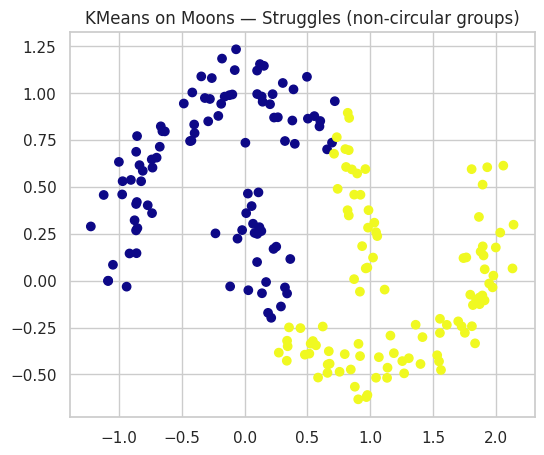

In [16]:
# ============================================
# SEGMENT 5B: KMeans on Moons — shows where clustering STRUGGLES
# ============================================
kmeans_moons = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans_moons.fit(X_moons)
labels_moons_km = kmeans_moons.labels_

plt.figure(figsize=(6, 5))
plt.scatter(X_moons[:, 0], X_moons[:, 1], c=labels_moons_km, cmap='plasma')
plt.title("KMeans on Moons — Struggles (non-circular groups)")
plt.show()
